In [3]:
import cv2

img = cv2.imread('test.jpg')
cv2.imshow('test', img)
cv2.waitKey(0)
cv2.destroyAllWindows()

qt.qpa.plugin: Could not find the Qt platform plugin "wayland" in "/home/mradul/opencv/venv/lib/python3.12/site-packages/cv2/qt/plugins"
QFontDatabase: Cannot find font directory /home/mradul/opencv/venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/mradul/opencv/venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/mradul/opencv/venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/mradul/opencv/venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (fr

In [4]:
print(type(img))
print(img.shape)

<class 'numpy.ndarray'>
(237, 382, 3)


In [5]:
print(img[0,0])

[33 33 33]


In [6]:
img[0,0] = [0,0,255]

opencv uses BGR order, matplotlib uses RGB order

In [7]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
cv2.imshow('test', img_rgb)
cv2.waitKey(0)
cv2.destroyAllWindows()
print(img_rgb[0,0])

[255   0   0]


In [8]:
cv2.imshow('test', img)
cv2.waitKey(0)
cv2.destroyAllWindows()
cv2.imshow('test', img_rgb)
cv2.waitKey(0)
cv2.destroyAllWindows()

imshow expects bgr, not rgb

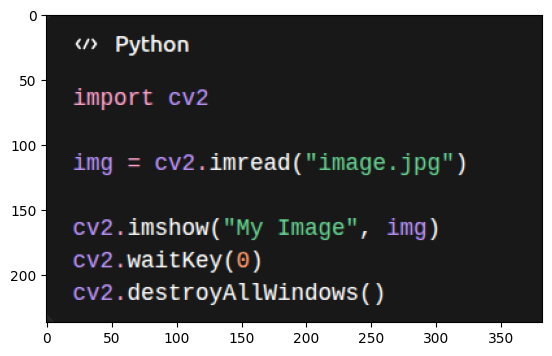

In [9]:
import matplotlib.pyplot as plt

plt.imshow(img_rgb)  # RGB required
plt.show()

image properties

In [10]:
print(img.shape)
print(img.size)

(237, 382, 3)
271602


In [11]:
print(img.dtype)

uint8


In [12]:
img[0,0] = [300, 0, 0]

OverflowError: Python integer 300 out of bounds for uint8

region of interest
[y, x]  → NOT (x, y)

In [14]:
roi = img[100:300, 200:400]
cv2.imshow("ROI", roi)
cv2.waitKey(0)
cv2.destroyAllWindows()

img[y1:y2, x1:x2]

y → vertical (rows)
x → horizontal (columns)

copy vs reference

In [15]:
img_copy = img
# this will not create a new image it just point to original image data

In [16]:
img_copy = img.copy()
# this is the correct way 

In [17]:
# crop center
h, w = img.shape[:2]

center = img[h//4:3*h//4, w//4:3*w//4]

cv2.imshow("Center Crop", center)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [19]:
# image split 
b, g, r = cv2.split(img)
cv2.imshow("Blue", b)
cv2.waitKey(0)
cv2.destroyAllWindows()

QFontDatabase: Cannot find font directory /home/mradul/opencv/venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/mradul/opencv/venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/mradul/opencv/venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/mradul/opencv/venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/mradul/opencv/ve

In [20]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

Gray = 0.299R + 0.587G + 0.114B

In [21]:
cv2.imshow("gray", gray)
cv2.waitKey(0)
cv2.destroyAllWindows()

hsv -> hue(color type), saturation(intensity), value(brightness)

In [22]:
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
cv2.imshow("hsv", hsv)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [23]:
import numpy as np

lower_red = np.array([0, 120, 70])
upper_red = np.array([10, 255, 255])

In [24]:
# create mask

mask = cv2.inRange(hsv, lower_red, upper_red)

In [26]:
# extract colour 
mask = cv2.inRange(hsv, lower_red, upper_red)
result = cv2.bitwise_and(img, img, mask=mask)

In [27]:
cv2.imshow("Original", img)
cv2.imshow("Mask", mask)
cv2.imshow("Result", result)

cv2.waitKey(0)
cv2.destroyAllWindows()

In HSV:

Red appears at both ends

In [28]:
lower1 = [0,120,70]
upper1 = [10,255,255]

lower2 = [170,120,70]
upper2 = [180,255,255]

Why HSV is BETTER than BGR

It separates:

Color (Hue)
Brightness (Value)

So:
You can detect colors even if lighting changes

Image Transformations

In [30]:
# resize 

resized = cv2.resize(img, (300, 300))

# or : maintain aspect ratio

h, w = img.shape[:2]

new_w = 300
new_h = int((new_w / w) * h)

resized = cv2.resize(img, (new_w, new_h))

In [32]:
# flip

flip1 = cv2.flip(img, 1)  # horizontal flip
flip2 = cv2.flip(img, 0)  # vertical flip
flip3 = cv2.flip(img, -1)  # both axes

cv2.imshow("Flipped", flip1)
cv2.imshow("Flipped", flip2)
cv2.imshow("Flipped", flip3)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [33]:
#rotation 

(h, w) = img.shape[:2]

center = (w//2, h//2)

matrix = cv2.getRotationMatrix2D(center, 45, 1)

rotated = cv2.warpAffine(img, matrix, (w, h))

cv2.imshow("Rotated", rotated)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [34]:
# translation

import numpy as np

matrix = np.float32([
    [1, 0, 100],  # move right
    [0, 1, 50]    # move down
])

shifted = cv2.warpAffine(img, matrix, (img.shape[1], img.shape[0]))
cv2.imshow("Shifted", shifted)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [35]:
# affine transformation

pts1 = np.float32([[50,50], [200,50], [50,200]])
pts2 = np.float32([[10,100], [200,50], [100,250]])

matrix = cv2.getAffineTransform(pts1, pts2)

result = cv2.warpAffine(img, matrix, (300,300))
cv2.imshow("Affine Transform", result)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [36]:
# perspective transformation

pts1 = np.float32([[100,100], [400,100], [100,400], [400,400]])
pts2 = np.float32([[0,0], [300,0], [0,300], [300,300]])

matrix = cv2.getPerspectiveTransform(pts1, pts2)

result = cv2.warpPerspective(img, matrix, (300,300))
cv2.imshow("Perspective Transform", result)
cv2.waitKey(0)
cv2.destroyAllWindows()